# XAI + DataDrift

이미지 데이터 피쳐에 대한 설명 가능한 드리프트 현상 검출

> 데이터 드리프트 검출 파이프라인에 XAI 기술 적용

## Pipeline Demo

데이터 수집 -> XAI map generation -> data comparison

### LOAD DATA & MODEL

In [ ]:
import os
import random
from PIL import Image
import numpy as np

# 지원하는 이미지 파일 확장자
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']

def get_random_image_from_path(data_path, num_images=1, keyword=None):
    """
    지정된 경로에서 랜덤하게 이미지를 선택합니다.
    
    Args:
        data_path (str): 이미지가 저장된 디렉토리 경로
        num_images (int): 선택할 이미지 개수 (기본값: 1)
        keyword (str): 파일명에 포함되어야 할 키워드 (기본값: "car")
    
    Returns:
        list: 선택된 이미지 파일 경로 리스트
    """
    # 디렉토리 내 모든 파일 검색
    all_files = []
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in IMAGE_EXTENSIONS):
                # 키워드가 파일명에 포함되어 있는지 확인
                if keyword.lower() in file.lower():
                    all_files.append(os.path.join(root, file))
    
    if not all_files:
        raise ValueError(f"'{data_path}' 경로에서 이미지 파일을 찾을 수 없습니다.")
    
    # 랜덤하게 이미지 선택
    selected_files = random.sample(all_files, min(num_images, len(all_files)))
    return selected_files

def display_random_images(data_path, num_images=3, figsize=(15, 5), keyword=None):
    """
    랜덤하게 선택된 이미지들을 출력합니다.
    
    Args:
        data_path (str): 이미지 디렉토리 경로
        num_images (int): 출력할 이미지 개수
        figsize (tuple): 그래프 크기
    """
    # 한글 폰트 설정
    setup_korean_font()
    
    try:
        # 랜덤 이미지 선택
        selected_files = get_random_image_from_path(data_path, num_images, keyword=keyword)
        
        # 이미지 출력
        fig, axes = plt.subplots(1, num_images, figsize=figsize)
        if num_images == 1:
            axes = [axes]
        
        for i, file_path in enumerate(selected_files):
            # 이미지 로드
            img = Image.open(file_path)
            
            # 이미지 표시
            axes[i].imshow(img)
            axes[i].set_title(f'이미지 {i+1}\n{os.path.basename(file_path)}', 
                            fontsize=12, fontweight='bold')
            axes[i].axis('off')
        
        plt.suptitle(f'"{keyword}" 키워드가 포함된 랜덤 이미지들', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
        # 선택된 파일 경로 출력
        print(f"\n'{keyword}' 키워드가 포함된 {len(selected_files)}개 이미지:")
        for i, file_path in enumerate(selected_files):
            print(f"{i+1}. {file_path}")
            
    except Exception as e:
        print(f"오류 발생: {e}")

한글 폰트 'AppleGothic' 적용 완료


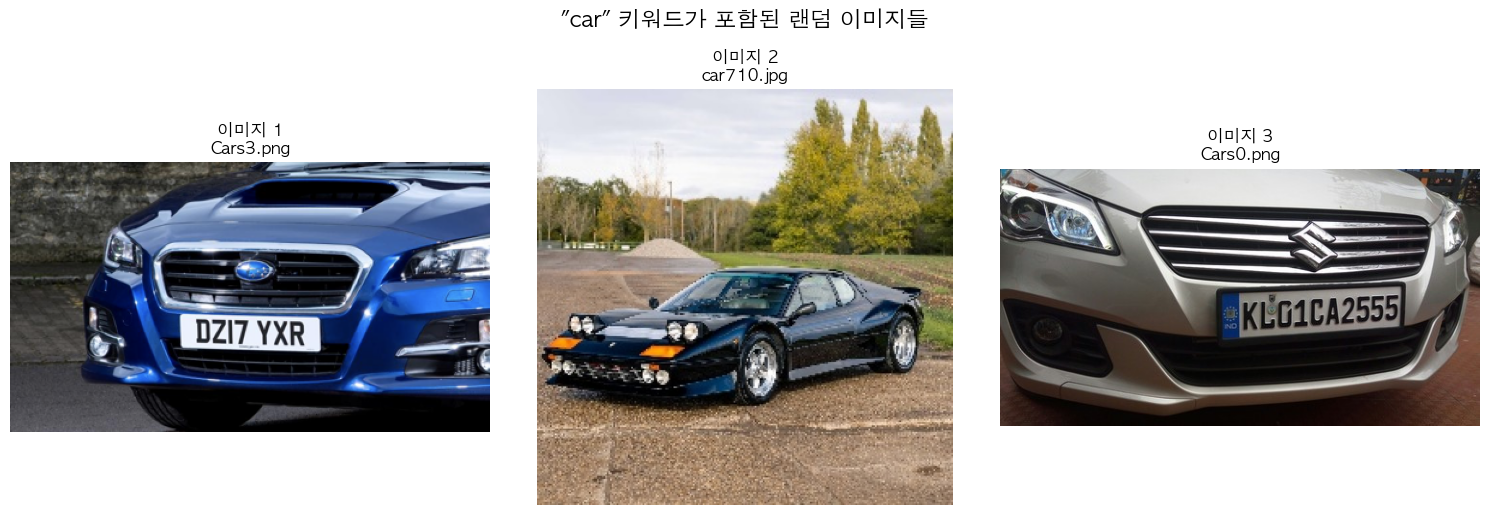


'car' 키워드가 포함된 3개 이미지:
1. ../datadoctor_cli_test/datasets/test_data2/Cars3.png
2. ../datadoctor_cli_test/datasets/test_data2/car710.jpg
3. ../datadoctor_cli_test/datasets/test_data2/Cars0.png


In [ ]:
data_path = "../datadoctor_cli_test/datasets/test_data2"

display_random_images(data_path, keyword="car")

In [ ]:
from ultralytics import YOLO

model_path = "yolov8n.pt"
model = YOLO(model_path)

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

### GENERATE XAI MAP

### COMPARE DADTA

* attetion drift

* confidence drift

* feature space drift

### QUANTIFICATION

* drift score